# 5. Demo Pipeline

A complete pipeline in one notebook: **download** raw volumes from two public
networks, **archive** them, **plot** them, and cut a **vertical cross-section**.

| radar | network | format | reader |
|---|---|---|---|
| `KDVN` | NEXRAD (US) — Davenport, Iowa | Level II | `open_nexradlevel2_datatree` |
| `FANJ` | FMI (Finland) — Anjalankoski | ODIM HDF5 | `open_odim_datatree` |

Both are public and need no credentials, and the cases below are only the
defaults — section 1 is where you pick a different time.

Two networks, two file formats, two continents — and neither needs any
preparation beyond the xradar reader that understands it.

In [1]:
import shutil
import tarfile
import urllib.parse
import urllib.request
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import xradar

import raddb
from raddb.lut import suggest_crs

print("raddb", raddb.__version__, "| xradar", xradar.__version__)

raddb 0.1.dev5+gde6070734.d20260323 | xradar 0.11.1


## Configuration

`RAW_DIR` is where the downloaded files land, `ARCHIVE_DIR` is the archive the
other tutorials use — the three radars below are simply added to it.

In [2]:
# --------------------------------------------------------------------------
# CONFIGURATION — edit these two paths to point at your own machine
# --------------------------------------------------------------------------
RAW_DIR = Path("~/Desktop/LTE_project/ltenas8/data/RADAR/tutorial_raw").expanduser()
ARCHIVE_DIR = Path("~/Desktop/LTE_project/ltenas8/users/giacobbi/raddb_tutorial_archive").expanduser()

RAW_DIR.mkdir(parents=True, exist_ok=True)

SOURCES = {
    # NEXRAD is mirrored on Google Cloud as one tar per radar per hour.
    "KDVN": {"kind": "nexrad", "site": "KDVN", "open": xradar.io.open_nexradlevel2_datatree},
    # FMI publishes one ODIM PVOL per volume.  The ODIM code is "fianj" — five
    # characters, where a RadDB radar name is at most four, so it is aliased.
    # Only the quarter-hour volumes are the full 13-sweep scan; see section 1.
    "FANJ": {"kind": "odim", "site": "fianj", "open": xradar.io.open_odim_datatree},
}

print("raw files:", RAW_DIR)
print("archive  :", ARCHIVE_DIR)

raw files: /home/erik_poschivo/Desktop/LTE_project/ltenas8/data/RADAR/tutorial_raw
archive  : /home/erik_poschivo/Desktop/LTE_project/ltenas8/users/giacobbi/raddb_tutorial_archive


## 1. Which volume?

**This is the cell to edit to run the demo on other weather.** One timestamp per
radar, UTC — the networks publish on their own days, so they are picked
independently. Each is resolved to the volume **at or after** the time asked for.

What each archive holds, if you go looking for another case:

* **NEXRAD** — the Google mirror is complete for 2024; one tar per radar per
  hour, ~10 volumes inside, so any hour of any day works.
* **FMI** — one file every **5 minutes**, but the scan strategy cycles over
  15 minutes: only `:00`, `:15`, `:30` and `:45` are the full 13-sweep volume,
  while `:05`/`:10` and their repeats are two shorter task sets. RadDB stores
  one geometry per radar, so the timestamp is rounded down to the **quarter
  hour** and mixing the three would be refused as a scan-strategy change.

In [3]:
# --------------------------------------------------------------------------
# WHICH TIMESTEP? — one UTC timestamp per radar, edit freely
# --------------------------------------------------------------------------
TIMES = {
    "KDVN": "2024-06-25 23:04",
    "FANJ": "2024-08-09 12:00",
}

for name, when in TIMES.items():
    print(f"{name:<5} {pd.Timestamp(when):%Y-%m-%d %H:%M} UTC")

KDVN  2024-06-25 23:04 UTC
FANJ  2024-08-09 12:00 UTC


## 2. Download

In [4]:
def resolve_url(source, when):
    """URL of the volume at or after *when* for one source."""
    t = pd.Timestamp(when)
    site = source["site"]

    if source["kind"] == "nexrad":
        obj = f"{t:%Y/%m/%d}/{site}/NWS_NEXRAD_NXL2DPBL_{site}" f"_{t:%Y%m%d%H}0000_{t:%Y%m%d%H}5959.tar"
        return (
            "https://storage.googleapis.com/download/storage/v1/b/gcp-public-data-nexrad-l2/o/"
            + urllib.parse.quote(obj, safe="")
            + "?alt=media"
        )

    # FMI: only the quarter-hour volumes carry the full 13-sweep scan strategy.
    t = t.floor("15min")
    return (
        "https://fmi-opendata-radar-volume-hdf5.s3.eu-west-1.amazonaws.com/"
        f"{t:%Y/%m/%d}/{site}/{t:%Y%m%d%H%M}_{site}_PVOL.h5"
    )


def download(url, dest_dir, when):
    """Fetch one volume into *dest_dir* and return its path."""
    if ".tar" in url:
        wanted = pd.Timestamp(when)
        with urllib.request.urlopen(url, timeout=600) as response, tarfile.open(fileobj=response, mode="r|") as tar:
            for member in tar:
                # KDVN20240625_230458_V06.ar2v — *_MDM.ar2v are metadata stubs.
                if not member.name.endswith(".ar2v") or "_MDM" in member.name:
                    continue
                stamp = pd.to_datetime(Path(member.name).stem[4:19], format="%Y%m%d_%H%M%S")
                if stamp < wanted:
                    continue
                out = dest_dir / Path(member.name).name
                with tar.extractfile(member) as src, open(out, "wb") as dst:
                    shutil.copyfileobj(src, dst)
                return out
        raise RuntimeError(f"no volume at or after {wanted} in {url}")

    out = dest_dir / Path(urllib.parse.urlparse(url).path).name
    if not out.exists():
        urllib.request.urlretrieve(url, out)
    return out


for name, source in SOURCES.items():
    url = resolve_url(source, TIMES[name])
    source["path"] = download(url, RAW_DIR, TIMES[name])
    print(f"{name:<5} {source['path'].name:<32} {source['path'].stat().st_size / 1e6:6.1f} MB")

KDVN  KDVN20240625_230458_V06.ar2v       15.1 MB
FANJ  202408091200_fianj_PVOL.h5         22.6 MB


## 3. Archive

Each file is opened with its own xradar reader and handed to `archive()` — no
preparation in between. A real volume often drops a ray or two (718 of 720 on
WSR-88D, 358 of 360 here); RadDB reads that as a rotation with holes, keeps the
missing rays' slots in the LUT so a later volume that records them still joins,
and archives what is there.

The CRS is **mandatory to write** and comes from `suggest_crs()`, which returns
the UTM zone of the site: two radars on two continents, two projections.

`FANJ` may already be in the archive from tutorial 1, where all three Finnish
radars were written in the national grid EPSG:3067. A radar's LUT is generated
once and then reused, so this volume joins the geometry that is already there and
the CRS printed below is only what `suggest_crs()` would have picked.

In [5]:
for name, source in SOURCES.items():
    dt = source["open"](str(source["path"]))
    site = dt["/"].ds
    crs = suggest_crs(latitude=float(site["latitude"]), longitude=float(site["longitude"]))
    print(
        f"{name}: {sum(1 for g in dt.groups if g.startswith('/sweep_'))} sweeps, "
        f"site {float(site['latitude']):.2f}, {float(site['longitude']):.2f} -> EPSG:{crs}",
    )

    raddb.RadDB(archive_dir=ARCHIVE_DIR, crs=crs).archive(datatree=dt, radar=name)

KDVN: 21 sweeps, site 41.61, -90.58 -> EPSG:32615


RadDB archive
  archive_dir : /home/erik_poschivo/Desktop/LTE_project/ltenas8/users/giacobbi/raddb_tutorial_archive
  crs         : 32615
  radars      : ['KDVN']
  filter      : keep DBZH > 0.0
  volumes     : 1 archived, 0 failed
  elapsed     : 12s


FANJ: 13 sweeps, site 60.90, 27.11 -> EPSG:32635


RadDB archive
  archive_dir : /home/erik_poschivo/Desktop/LTE_project/ltenas8/users/giacobbi/raddb_tutorial_archive
  crs         : 32635
  radars      : ['FANJ']
  filter      : keep DBZH > 0.0
  volumes     : 1 archived, 0 failed
  elapsed     : 2s


In [6]:
db = raddb.RadDB(archive_dir=ARCHIVE_DIR)
db.inventory()

RadDB inventory — archived data
  archive_dir : /home/erik_poschivo/Desktop/LTE_project/ltenas8/users/giacobbi/raddb_tutorial_archive
  radars      : FANJ, FKOR, FKUO, KDVN, KLOT, KMLB, KTLX
  volumes     : 52
  time range  : 2024-06-01 12:00:01 .. 2024-08-09 12:00:03
------------------------------------------------------------------------------
  radar   volumes  time range                                           size
  FANJ         14  2024-06-01 12:00:02 .. 2024-08-09 12:00:03        29.9 MB
  FKOR         14  2024-06-01 12:00:01 .. 2024-06-14 12:00:01        13.3 MB
  FKUO         14  2024-06-01 12:00:05 .. 2024-06-14 12:00:05        25.9 MB
  KDVN          1  2024-06-25 23:04:58                               17.6 MB
  KLOT          0  unknown (no timestamp in the filenames)               0 B
  KMLB          1  2024-06-12 22:57:27                                7.1 MB
  KTLX          8  2024-06-12 22:03:24 .. 2024-06-12 22:53:30        59.3 MB
------------------------------------

## 4. Plot


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



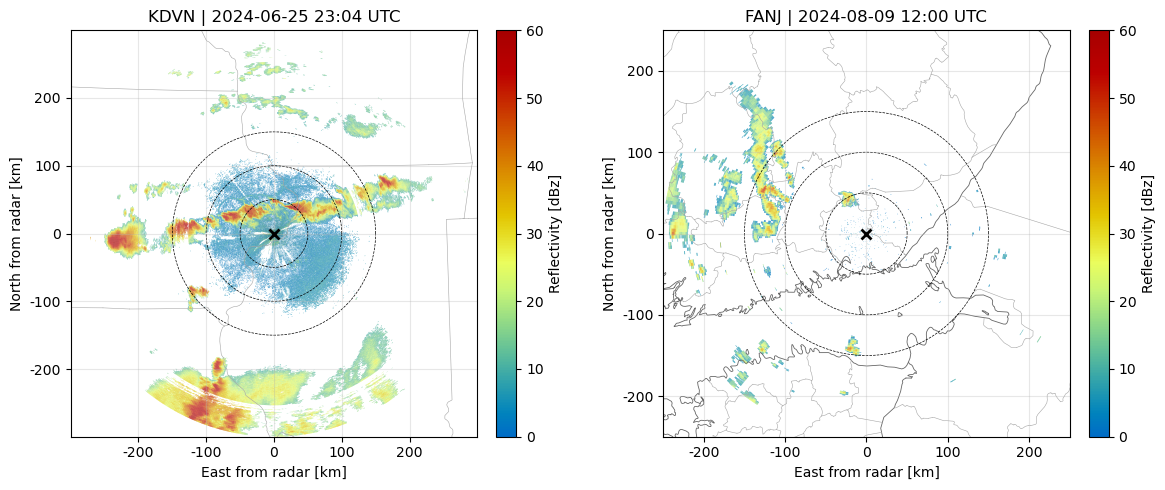

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

volumes = {}
for ax, name in zip(axes, SOURCES, strict=False):
    # A radar may already hold other volumes from tutorial 1, so name the one
    # this notebook just archived rather than letting plot_ppi guess.
    volumes[name] = db.open(radars=name)
    volumes[name].plot_ppi(
        sweep=1, variable="DBZH", ax=ax, coords="xy", context=True, timestep=TIMES[name],
    )
    ax.set_title(f"{name} | {pd.Timestamp(TIMES[name]):%Y-%m-%d %H:%M} UTC")

plt.tight_layout()
plt.show()

## 5. A cross-section, drawn by hand

`interactive_crop()` puts an [ipyleaflet](https://ipyleaflet.readthedocs.io/) map
in front of you. It dispatches on the shape you draw — rectangle, polygon and
marker run the three crops, and the **polyline** runs
`extract_cross_section`, which is the one used here.

Draw a line, then click **Apply crop** before running the next cell.

In [8]:
kdvn = volumes["KDVN"]
selector = kdvn.interactive_crop()

The drawn section is on `selector.result` — an ordinary RadDB, carrying the extra
`d_center` / `z_center` / `cs_polygon` columns that describe the curtain. Nothing
drawn (or no live kernel) falls back to a fixed line through the same storm, so
the plot below always has a section to draw.

nothing drawn — using the fixed line ((-91.3, 40.95), (-91.3, 42.1)): 2,655 gates


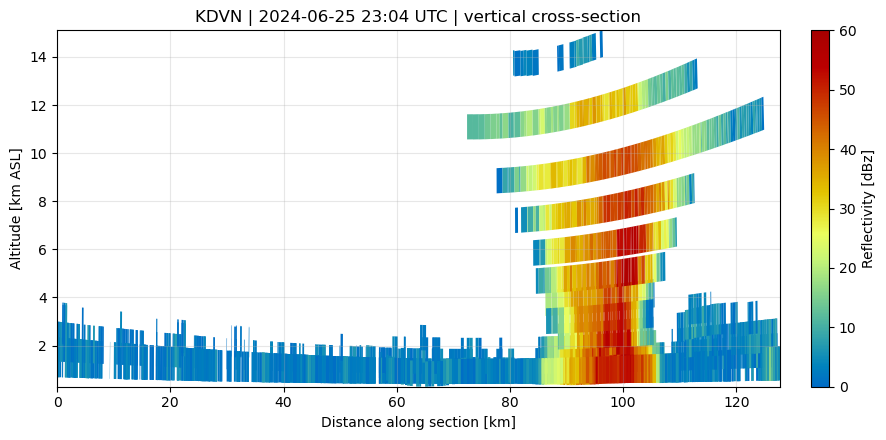

In [9]:
LINE = ((-91.30, 40.95), (-91.30, 42.10))  # fallback: north-south through the strongest cell

drawn = getattr(selector, "result", None)
if drawn is not None and selector.kind == "cross_section":
    section = drawn
    print(f"drawn section: {len(section):,} gates")
else:
    section = kdvn.extract_cross_section(p1=LINE[0], p2=LINE[1], crs=4326)
    print(f"nothing drawn — using the fixed line {LINE}: {len(section):,} gates")

fig, ax = plt.subplots(figsize=(9, 4.5))
section.plot_vcs(variable="DBZH", ax=ax)
ax.set_title(f"KDVN | {pd.Timestamp(TIMES['KDVN']):%Y-%m-%d %H:%M} UTC | vertical cross-section")
plt.tight_layout()
plt.show()

---

That is the whole pipeline: **download → archive → open → plot → cut**. The
archive now holds two more radars, and everything the other notebooks do —
filters, label selection, the other three crops, RHI, CAPPI — applies to them
unchanged.

**See also:** [1 — Archiving](01_archiving.ipynb) ·
[2 — Opening and filtering](02_opening_and_filtering.ipynb) ·
[3 — Areas of interest](03_area_of_interest.ipynb) ·
[4 — Plots](04_plots.ipynb)